# Movie Recommendation System - Part 4: Hybrid Model

This notebook implements a Hybrid Recommender System that merges:
- **Collaborative Filtering SVD predictions** (personalization latent factors).
- **Content-Based Genome similarities** (content profile relevance).

We combine these predictions linearly and evaluate the performance.


### Step 1: Import Required Libraries
Import tools for hybrid blending, plotting, and analytics.


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


### Step 2: Load Datasets, Saved Models, and Similarities
Load the datasets and serialized similarity structures.


In [2]:
movies = pd.read_csv('movies_sampled.csv')
ratings = pd.read_csv('ratings_sampled.csv')

with open('surprise_svd_model.pkl', 'rb') as f:
    svd = pickle.load(f)
    
genome_sim = np.load('genome_similarity.npy')
genome_movie_ids = np.load('genome_movie_ids.npy').tolist()
movie_id_to_genome_idx = {movie_id: idx for idx, movie_id in enumerate(genome_movie_ids)}

print(f'Loaded {len(movies)} movies and datasets successfully.')


Loaded 3159 movies and datasets successfully.


### Step 3: Implement Hybrid Recommendation Logic
The Hybrid Score is defined as:
$$\text{Hybrid Score}(u, m) = \alpha \times \text{SVD Score}(u, m) + (1 - \alpha) \times \text{Content Score}(u, m)$$

- **SVD Score**: Predicted user rating normalized to a $[0, 1]$ range.
- **Content Score**: The average cosine similarity of the candidate movie to the movies the user rated highly ($\ge 4.0$).


In [3]:
def get_hybrid_recommendations(user_id, top_n=5, alpha=0.5):
    user_ratings = ratings[ratings['userId'] == user_id]
    high_rated = user_ratings[user_ratings['rating'] >= 4.0]
    if high_rated.empty:
        high_rated = user_ratings
        
    user_favorite_movie_ids = high_rated['movieId'].tolist()
    
    rated_movie_ids = set(user_ratings['movieId'])
    all_movie_ids = movies['movieId'].unique()
    unrated_movie_ids = [mid for mid in all_movie_ids if mid not in rated_movie_ids]
    
    # Collaborative SVD prediction (normalized)
    svd_scores = {}
    for mid in unrated_movie_ids:
        pred = svd.predict(user_id, mid)
        svd_scores[mid] = (pred.est - 0.5) / 4.5  # normalize from [0.5, 5] to [0, 1]
        
    # Content-based genome similarity
    content_scores = {}
    fav_genome_indices = [movie_id_to_genome_idx[mid] for mid in user_favorite_movie_ids if mid in movie_id_to_genome_idx]
    
    for mid in unrated_movie_ids:
        if mid in movie_id_to_genome_idx and fav_genome_indices:
            target_idx = movie_id_to_genome_idx[mid]
            similarities = genome_sim[target_idx, fav_genome_indices]
            content_scores[mid] = np.mean(similarities)
        else:
            content_scores[mid] = 0.0
            
    # Combine SVD and Content scores
    hybrid_scores = []
    for mid in unrated_movie_ids:
        collab_score = svd_scores.get(mid, 0.0)
        cont_score = content_scores.get(mid, 0.0)
        combined_score = alpha * collab_score + (1.0 - alpha) * cont_score
        hybrid_scores.append((mid, combined_score, collab_score, cont_score))
        
    hybrid_scores.sort(key=lambda x: x[1], reverse=True)
    top_hybrid = hybrid_scores[:top_n]
    
    rec_ids = [x[0] for x in top_hybrid]
    rec_movies = movies[movies['movieId'].isin(rec_ids)].copy()
    
    mapping_score = {x[0]: x[1] for x in top_hybrid}
    mapping_collab = {x[0]: x[2] for x in top_hybrid}
    mapping_content = {x[0]: x[3] for x in top_hybrid}
    
    rec_movies['hybrid_score'] = rec_movies['movieId'].map(mapping_score)
    rec_movies['collab_score_norm'] = rec_movies['movieId'].map(mapping_collab)
    rec_movies['content_score_norm'] = rec_movies['movieId'].map(mapping_content)
    rec_movies = rec_movies.sort_values(by='hybrid_score', ascending=False)
    return rec_movies[['title', 'genres', 'hybrid_score', 'collab_score_norm', 'content_score_norm']]


### Step 4: Generate Recommendations for a Sample User
Verify recommendations with equal weight ($0.5$ / $0.5$).


In [4]:
sample_user_id = ratings['userId'].iloc[0]
print(f'=== Hybrid Recommendations for User {sample_user_id} (alpha=0.5) ===')
print(get_hybrid_recommendations(sample_user_id, 5, alpha=0.5))


=== Hybrid Recommendations for User 116 (alpha=0.5) ===
                              title  \
2946        Dark Knight, The (2008)   
3135        Django Unchained (2012)   
3064               Inception (2010)   
2860                     300 (2007)   
3113  Dark Knight Rises, The (2012)   

                                               genres  hybrid_score  \
2946                          Action|Crime|Drama|IMAX      0.809005   
3135                             Action|Drama|Western      0.776759   
3064  Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX      0.766907   
2860                          Action|Fantasy|War|IMAX      0.760450   
3113                      Action|Adventure|Crime|IMAX      0.752394   

      collab_score_norm  content_score_norm  
2946           0.858959            0.759051  
3135           0.815887            0.737631  
3064           0.802278            0.731537  
2860           0.810218            0.710681  
3113           0.776223            0.728565  


### Step 5: Sensitivity Analysis of Weight Parameter (alpha)
See how the recommendations change when transitioning from pure SVD collaborative filtering ($\alpha=1.0$) to balanced hybrid ($\alpha=0.5$) and pure tag genome filtering ($\alpha=0.0$).


In [5]:
print('=== Pure Collaborative (alpha=1.0) ===')
print(get_hybrid_recommendations(sample_user_id, 3, alpha=1.0)[['title', 'hybrid_score']])
print('\n=== Balanced Hybrid (alpha=0.5) ===')
print(get_hybrid_recommendations(sample_user_id, 3, alpha=0.5)[['title', 'hybrid_score']])
print('\n=== Pure Content-Based (alpha=0.0) ===')
print(get_hybrid_recommendations(sample_user_id, 3, alpha=0.0)[['title', 'hybrid_score']])


=== Pure Collaborative (alpha=1.0) ===
                        title  hybrid_score
2946  Dark Knight, The (2008)      0.858959
3135  Django Unchained (2012)      0.815887
2860               300 (2007)      0.810218

=== Balanced Hybrid (alpha=0.5) ===
                        title  hybrid_score
2946  Dark Knight, The (2008)      0.809005
3135  Django Unchained (2012)      0.776759
3064         Inception (2010)      0.766907

=== Pure Content-Based (alpha=0.0) ===
                              title  hybrid_score
2946        Dark Knight, The (2008)      0.759051
2897            3:10 to Yuma (2007)      0.758931
2082  Magnificent Seven, The (1960)      0.754113


### Step 6: Quantitative Comparison of Recommended Movie Quality
Compare SVD-only, Content-only, and Hybrid models on collaborative score distribution across a random set of 10 users.


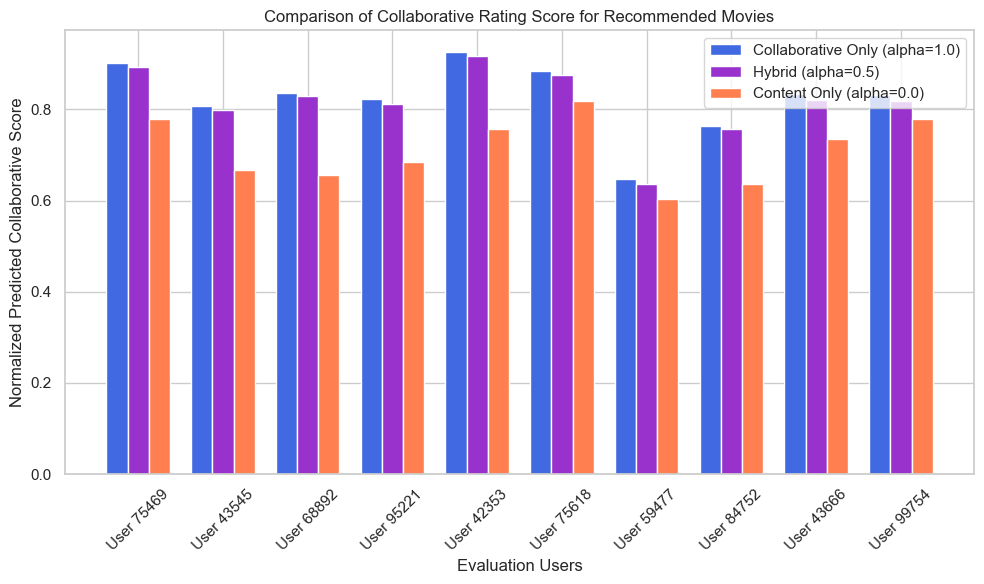

Comparison plot successfully generated and saved as "model_comparison.png".


In [6]:
np.random.seed(42)
eval_users = np.random.choice(ratings['userId'].unique(), size=10, replace=False)

collab_avgs = []
content_avgs = []
hybrid_avgs = []

for uid in eval_users:
    collab_rec = get_hybrid_recommendations(uid, 10, alpha=1.0)
    collab_avgs.append(collab_rec['collab_score_norm'].mean())
    
    content_rec = get_hybrid_recommendations(uid, 10, alpha=0.0)
    content_avgs.append(content_rec['collab_score_norm'].mean())
    
    hybrid_rec = get_hybrid_recommendations(uid, 10, alpha=0.5)
    hybrid_avgs.append(hybrid_rec['collab_score_norm'].mean())
    
plt.figure(figsize=(10, 6))
x = np.arange(len(eval_users))
width = 0.25

plt.bar(x - width, collab_avgs, width, label='Collaborative Only (alpha=1.0)', color='royalblue')
plt.bar(x, hybrid_avgs, width, label='Hybrid (alpha=0.5)', color='darkorchid')
plt.bar(x + width, content_avgs, width, label='Content Only (alpha=0.0)', color='coral')

plt.title('Comparison of Collaborative Rating Score for Recommended Movies')
plt.xlabel('Evaluation Users')
plt.ylabel('Normalized Predicted Collaborative Score')
plt.xticks(x, [f'User {uid}' for uid in eval_users], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print('Comparison plot successfully generated and saved as "model_comparison.png".')


### Step 7: Summary Analysis of Recommendation Approaches
A comparison of strengths, weaknesses, and hybrid benefits.


In [7]:
summary = '''
=== Recommendation Paradigm Analysis ===

1. Content-Based Filtering:
   - Strengths: No cold-start problem for new movies. Highly explainable.
   - Weaknesses: Overspecialization (fails to recommend items outside user\'s history). Requires rich tag profiles.

2. Collaborative Filtering (Matrix Factorization - SVD):
   - Strengths: Highly personalized. Captures latent user-item interactions and finds serendipitous recommendations.
   - Weaknesses: Severe cold-start problem for new users/items. Sparsity limits prediction quality.

3. Hybrid Model:
   - Strengths: Combines best of both worlds. Leverages the accuracy of collaborative filters with the semantic profiles of content-based tags.
   - Weaknesses: Higher runtime complexity (requires collaborative prediction and item-similarity checks).
'''
print(summary)



=== Recommendation Paradigm Analysis ===

1. Content-Based Filtering:
   - Strengths: No cold-start problem for new movies. Highly explainable.
   - Weaknesses: Overspecialization (fails to recommend items outside user's history). Requires rich tag profiles.

2. Collaborative Filtering (Matrix Factorization - SVD):
   - Strengths: Highly personalized. Captures latent user-item interactions and finds serendipitous recommendations.
   - Weaknesses: Severe cold-start problem for new users/items. Sparsity limits prediction quality.

3. Hybrid Model:
   - Strengths: Combines best of both worlds. Leverages the accuracy of collaborative filters with the semantic profiles of content-based tags.
   - Weaknesses: Higher runtime complexity (requires collaborative prediction and item-similarity checks).

